In [50]:
'''
Tree Based Algorithm
-decision tree ma overfitting hunxa as it works on the basis of one question
-to overcome overfitting from decision tree random forest is used
-random forest asks question multiple times by taking multiple records and creating multiple trees from the records

-> Decision Tree
    -Tree Based Learning

-> Random Forest
    -Tree Based and Ensemble Learning

'''

'\nTree Based Algorithm\n-decision tree ma overfitting hunxa as it works on the basis of one question\n-to overcome overfitting from decision tree random forest is used\n-random forest asks question multiple times by taking multiple records and creating multiple trees from the records\n\n-> Decision Tree\n    -Tree Based Learning\n\n-> Random Forest\n    -Tree Based and Ensemble Learning\n\n'

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Decision Tree
from sklearn.tree import DecisionTreeClassifier
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

In [52]:
df = pd.read_csv('D:\Data Science\Dataset\Fraud Detection Dataset.csv')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Acer\AppData\Local\Temp\ipykernel_10020\1378361031.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv('D:\Data Science\Dataset\Fraud Detection Dataset.csv')


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [53]:
df.isnull().sum()

Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64

In [54]:
df.drop_duplicates(subset='Transaction_ID', keep='first', inplace=True)

In [55]:
total_transaction = df['Transaction_ID'].count()
total_transaction

50000

In [56]:
non_fradulent = df[df['Fraudulent']==0]['Transaction_ID'].count()
non_fradulent

47540

In [57]:
yes_fradulent = df[df['Fraudulent']==1]['Transaction_ID'].count()
yes_fradulent

2460

In [58]:
df.fillna({
    'Transaction_Amount': df['Transaction_Amount'].median(),
    'Time_of_Transaction': df['Time_of_Transaction'].mode()[0]
}, inplace=True)

In [59]:
df.fillna({
    'Device_Used':'Unknown Device',
    'Location': 'Unknown Location',
    'Payment_Method':'Unknown Method'
}, inplace=True)

In [60]:
df.columns

Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Time_of_Transaction', 'Device_Used', 'Location',
       'Previous_Fraudulent_Transactions', 'Account_Age',
       'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent'],
      dtype='object')

In [61]:
columns =['Transaction_Type','Device_Used','Location','Payment_Method']
le = LabelEncoder()

for col in columns:
    df[f'{col}_id'] = le.fit_transform(df[col])

## Features and Target

In [62]:
df.columns

Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Time_of_Transaction', 'Device_Used', 'Location',
       'Previous_Fraudulent_Transactions', 'Account_Age',
       'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent',
       'Transaction_Type_id', 'Device_Used_id', 'Location_id',
       'Payment_Method_id'],
      dtype='object')

In [63]:
features = ['Transaction_Amount', 'Transaction_Type_id','Time_of_Transaction',
            'Device_Used_id','Location_id','Previous_Fraudulent_Transactions',
            'Account_Age','Number_of_Transactions_Last_24H',
            'Payment_Method_id']
target = 'Fraudulent'

In [64]:
X = df[features]
Y = df[target]

## Train Test Split

In [65]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y, test_size=0.2, random_state=42, stratify=Y
)

## Feature Scaling

In [66]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

## Decision Tree Implementation

In [70]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)
dt_model.fit(X_train_scale, Y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [71]:
dt_pred = dt_model.predict(X_test_scale)

In [72]:
dt_cr = classification_report(Y_test, dt_pred)
dt_cm = confusion_matrix(Y_test, dt_pred)

In [73]:
print(dt_cr)

              precision    recall  f1-score   support

           0       0.95      0.51      0.67      9508
           1       0.05      0.48      0.09       492

    accuracy                           0.51     10000
   macro avg       0.50      0.50      0.38     10000
weighted avg       0.91      0.51      0.64     10000



In [74]:
print(dt_cm)

[[4892 4616]
 [ 258  234]]


<Axes: >

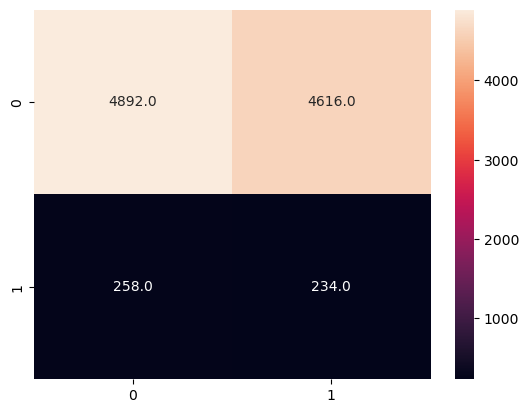

In [76]:
sns.heatmap(dt_cm, annot=True, fmt = '1.1f')